<a href="https://colab.research.google.com/github/palakbari/Machine-Learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Least Square Method

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
raw_data = fetch_california_housing(as_frame=True)
df = raw_data.frame

In [ ]:
df_sample = df.sample(n=300, random_state=42).sort_values(by='MedInc')

X = df_sample[['MedInc']].values
y = df_sample['MedHouseVal'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset loaded. Training shapes: X={X_train.shape}, y={y_train.shape}")
df_sample[['MedInc', 'MedHouseVal']].head()

Dataset loaded. Training shapes: X=(240, 1), y=(240, 1)


,MedInc,MedHouseVal
5216,0.8527,0.904
5226,0.9298,1.000
19485,0.9336,1.271
4591,1.2254,1.625
4852,1.2300,1.384


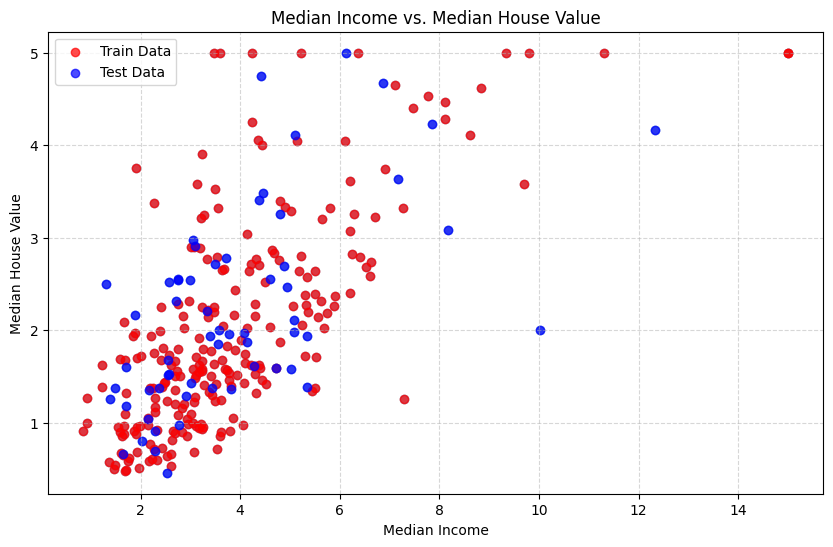

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_sample['MedInc'], df_sample['MedHouseVal'], alpha=0.5)
plt.scatter(X_train, y_train, color='red', alpha=0.7, label='Train Data')
plt.scatter(X_test, y_test, color='blue', alpha=0.7, label='Test Data')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.title('Median Income vs. Median House Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

w = (X^T * X) * X^T * y

In [ ]:
X_train_bias = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_bias = np.c_[np.ones((len(X_test), 1)), X_test]

In [ ]:
theta = np.linalg.inv(X_train_bias.T.dot(X_train_bias)).dot(X_train_bias.T).dot(y_train)

intercept, slope = theta[0][0], theta[1][0]
print(f"Calculated Intercept (w0): {intercept:.4f}")
print(f"Calculated Slope (w1): {slope:.4f}")

Calculated Intercept (w0): 0.5117
Calculated Slope (w1): 0.3914


In [ ]:
pred_ols = X_test_bias.dot(theta)

Polynomial Regression

In [ ]:
def get_poly_features(X_matrix, degree=3):
  return np.hstack([X_matrix ** i for i in range(1, degree + 1)])

In [ ]:
x_train_poly = get_poly_features(X_train, degree=3)
x_test_poly = get_poly_features(X_test, degree=3)

In [ ]:
theta_poly = np.linalg.inv(x_train_poly.T.dot(x_train_poly)).dot(x_train_poly.T).dot(y_train)

In [ ]:
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_line_poly = get_poly_features(X_line, degree=3)
y_line_poly_line = X_line_poly.dot(theta_poly)

In [ ]:
y_pred_poly = x_test_poly.dot(theta_poly)
print("Polynomial coefficient computed successfully.")

Polynomial coefficient computed successfully.


Ridge and Lasso Regularization

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

Multivariate Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
raw_data = fetch_california_housing(as_frame=True)
df = raw_data.frame

In [ ]:
df.corr()['MedInc'].sort_values(ascending=False)

,MedInc
MedInc,1.000000
MedHouseVal,0.688075
AveRooms,0.326895
AveOccup,0.018766
Population,0.004834
Longitude,-0.015176
AveBedrms,-0.062040
Latitude,-0.079809
HouseAge,-0.119034


In [ ]:
df_sample = df.sample(n=300, random_state=42).sort_values(by='MedInc')

X = df_sample[['MedHouseVal', 'AveRooms']].values
y = df_sample['MedInc'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset loaded. Training shapes: X={X_train.shape}, y={y_train.shape}")
df_sample[['MedInc', 'MedHouseVal', 'AveRooms']].head()

Dataset loaded. Training shapes: X=(240, 2), y=(240, 1)


,MedInc,MedHouseVal,AveRooms
5216,0.8527,0.904,3.432900
5226,0.9298,1.000,3.676162
19485,0.9336,1.271,3.662745
4591,1.2254,1.625,2.096692
4852,1.2300,1.384,5.367347


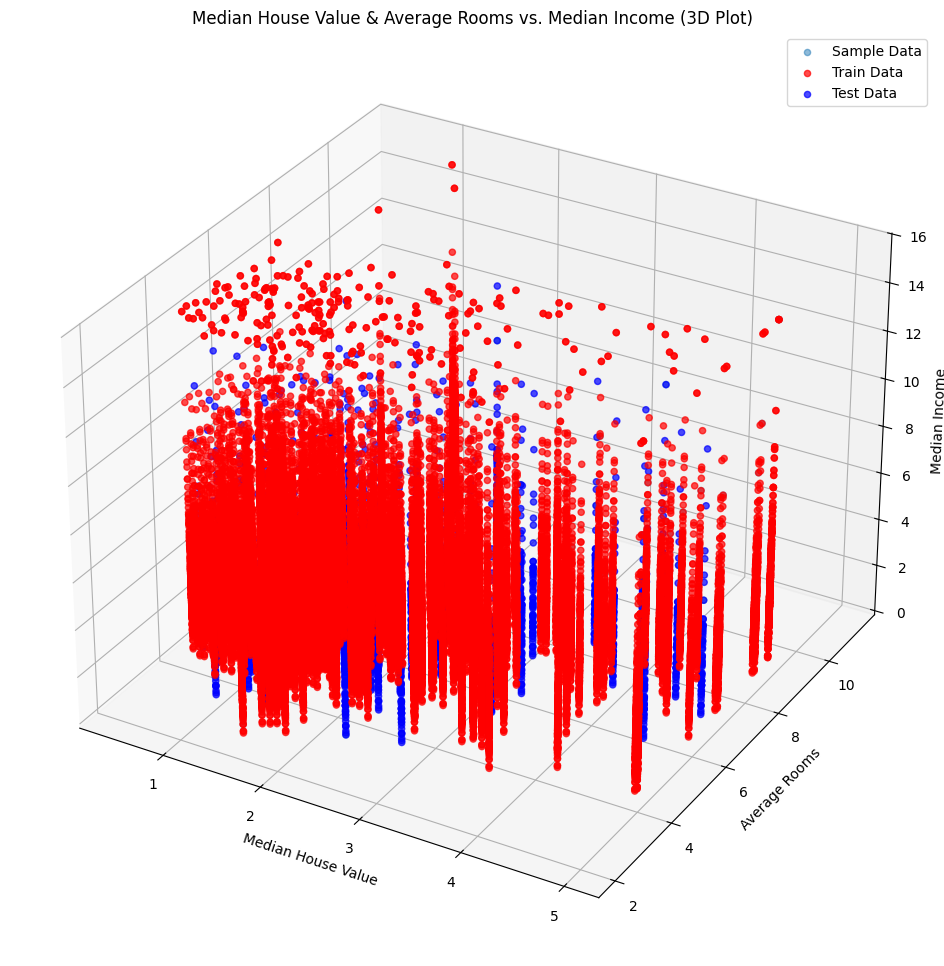

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_sample['MedHouseVal'], df_sample['AveRooms'], df_sample['MedInc'], alpha=0.5, label='Sample Data')


ax.scatter(X_train[:, 0], X_train[:, 1], y_train, color='red', alpha=0.7, label='Train Data')
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, color='blue', alpha=0.7, label='Test Data')

ax.set_xlabel('Median House Value')
ax.set_ylabel('Average Rooms')
ax.set_zlabel('Median Income')
ax.set_title('Median House Value & Average Rooms vs. Median Income (3D Plot)')
ax.legend()
plt.show()

In [ ]:
X_train_bias_multi = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_bias_multi = np.c_[np.ones((len(X_test), 1)), X_test]

In [ ]:
theta_multi = np.linalg.inv(X_train_bias_multi.T.dot(X_train_bias_multi)).dot(X_train_bias_multi.T).dot(y_train)

print(f"Calculated Coefficients (theta):\n{theta_multi}")

Calculated Coefficients (theta):
[[-1.83664821]
 [ 1.00206817]
 [ 0.69461358]]


In [ ]:
y_pred_multi = X_test_bias_multi.dot(theta_multi)

In [ ]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print(f"Mean Squared Error: {mse_multi:.4f}")
print(f"R-squared: {r2_multi:.4f}")

Mean Squared Error: 1.3329
R-squared: 0.6876


Classification using Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
X = X[y != 2]
y = y[y != 2]

In [5]:
X = X[:, :2]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
X_train_aug = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test_aug = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

In [8]:
theta = np.linalg.inv(X_train_aug.T @ X_train_aug) @ X_train_aug.T @ y_train

In [9]:
y_pred_prob = X_test_aug @ theta
y_pred = (y_pred_prob >= 0.5).astype(int)

In [10]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[12  0]
 [ 0  8]]

Accuracy: 1.0


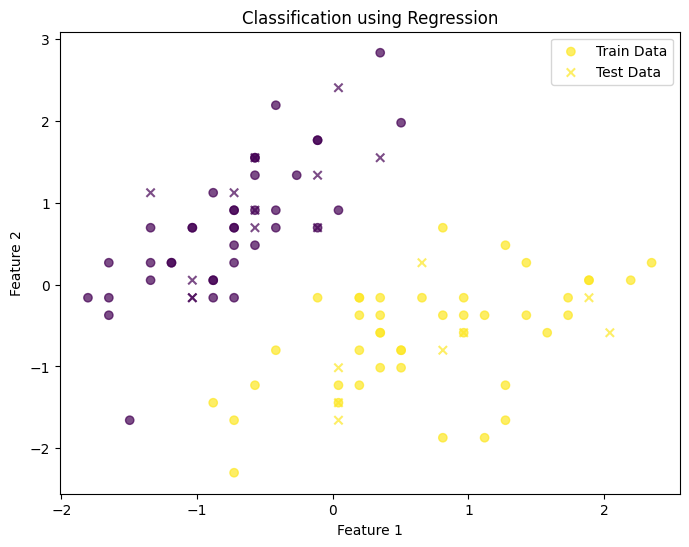

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', alpha=0.7, marker='x')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Classification using Regression')
plt.legend(['Train Data', 'Test Data'])
plt.show()

# SVM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn import svm

In [ ]:
bcancer = load_breast_cancer()
bcancer.feature_names
print(bcancer.feature_names)
bcancer.target_names
print(bcancer.target_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


In [ ]:
bcancer.data.shape

(569, 30)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(bcancer.data, bcancer.target, test_size=0.2, random_state=42)

In [ ]:
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Model Build")

Model Build


In [ ]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1-Score", metrics.f1_score(y_test, y_pred))

Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
F1-Score 0.9655172413793104


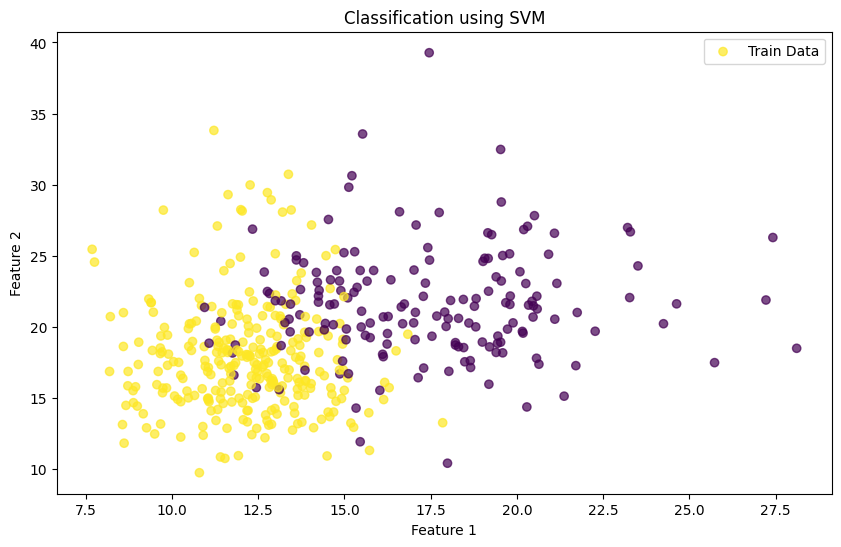

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.legend(['Train Data'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Classification using SVM')
plt.show()

In [ ]:
from sklearn.metrics.pairwise import linear_kernel
linear_kernel(X_train, X_train)
